# 11 · E3b: what is the drift?

**Where E3 left off (Notebook 10, 68 Atanas et al. recordings).**
* A connectome-free program fitted on the past goes stale; the drift exceeds each recording's own surrogate-calibrated threshold in 48/68 recordings.
* **No compact, activity-driven meta-program absorbs it.** Absorption has a median of −0.04 and a maximum of 0.25 (threshold 0.5).
* Pre-registered verdicts: **47 rewired**, 11 stationary, 10 stationary but underpowered, 0 self-programming.

"Rewired" means only that the drift is *not absorbed by slow states that modulate drives from neural activity*. Two alternatives remain, and this notebook tests both:

| | hypothesis | test |
|---|---|---|
| **A** | the drift is a change in **how neurons encode behavior**, which Atanas et al. reported for specific neurons (`encoding_changing_neurons`, comparing the two halves of each recording) | is per-neuron drift larger in the neurons the authors flagged? |
| **B** | the drift is a slow **behavioral state** (e.g. roaming vs dwelling), which instantaneous behavior inputs miss | does adding slowly filtered behavior (1- and 4-min timescales) shrink the drift gap, *beyond* what time-shifted behavior does? |

If **A** holds, the program changes in a specific, interpretable way: the mapping from behavior to activity is rewritten in identified neurons. That is a sharper version of Brette's claim than "drift". If **B** holds, the drift is state-dependence of a fixed program, and the computer metaphor survives with behavioral state as an input.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, glob, time, datetime, numpy as np, matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 10, 0), \
    f"Notebook 11 needs closurebench >= 0.10.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import drift as DR
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CONF = {"smoke": dict(N_SURR=1, MAX_FILES=1), "laptop": dict(N_SURR=2, MAX_FILES=None), "full": dict(N_SURR=3, MAX_FILES=None)}[MODE]
globals().update(CONF)
TAUS, N_WINDOWS, GAP_FLOOR = (60.0, 240.0), 8, 0.005
TAG = "" if MODE == "full" else f"_{MODE}"
files = sorted(glob.glob(os.path.join(RESULTS, "spontaneous", "*.json")))[:MAX_FILES]
CK = os.path.join(RESULTS, "e3b_ck", MODE); os.makedirs(CK, exist_ok=True)
print(f"{len(files)} recordings; {N_SURR} surrogates per input set; checkpoints in {CK}")

68 recordings; 2 surrogates per input set; checkpoints in /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/e3b_ck/laptop


### Pre-registration (before §1)

Recorded in `results/E3b_preregistration*.json`.

**A: encoding change.** For each recording, diff = mean per-neuron drift of the flagged neurons − mean of the others.
* Per-neuron drift is the R² gained, when forecasting the last quarter, by a program fitted on the 3rd quarter over one fitted on the first half.
* **Enrichment** holds if a Wilcoxon signed-rank test across recordings gives p < 0.05 with a positive median diff, **and** the same test on stationary surrogates is not significant.

**B: slow behavioral state.** For each recording, the forecast gap (refit − frozen) is computed with three input sets:
* instantaneous behavior (as in Notebook 10);
* + slow behavior (causal low-pass at 60 s and 240 s);
* + slow behavior **circularly shifted** by half the recording (control).

Two statistics follow:
* **Behavior-specific absorption:** the reduction in gap from true slow behavior exceeds the reduction from shifted slow behavior (Wilcoxon p < 0.05, positive median).
* **Slow behavioral state explains the drift** if, in addition, the number of drift-detected recordings (gap ≥ the recording's surrogate threshold for that input set) at least halves.

In [3]:
prereg = os.path.join(RESULTS, f"E3b_preregistration{TAG}.json")
plan = {"experiment": "E3b what is the drift", "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "config": {**CONF, "TAUS": list(TAUS), "N_WINDOWS": N_WINDOWS},
        "A": "Wilcoxon over recordings of diff = mean drift(flagged) - mean drift(other) > 0, p < 0.05; and n.s. on stationary surrogates",
        "B_specific": "Wilcoxon over recordings of (gap_inst - gap_slow) - (gap_inst - gap_shifted) > 0, p < 0.05",
        "B_explains": "B_specific and the number of drift-detected recordings with slow behavior <= half of that with instantaneous behavior"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E3b_preregistration_laptop.json


## 1 · Per-recording analysis (checkpointed)

About 1–2 minutes per recording on a laptop. Each recording is saved as soon as it is done, so a re-run resumes.

In [4]:
def gap_and_threshold(X, S, U, seed0=0):
    r = DR.analyse(X, S, n_windows=N_WINDOWS, d_grid=(), U=U)
    null = [DR.analyse(Y, S, n_windows=N_WINDOWS, d_grid=(), U=U)["gap"]
            for Y in (DR.surrogate(X, S, U, seed=seed0 + s) for s in range(N_SURR)) if Y is not None]
    return r["gap"], max([GAP_FLOOR] + null)

rec = {}
for f in files:
    name = os.path.basename(f).replace(".json", "")[-13:]
    ck = os.path.join(CK, name + ".json")
    if os.path.exists(ck):
        rec[name] = json.load(open(ck)); continue
    t0 = time.time()
    R = DR.load_atanas(f); X, U, dt = R["X"], R["U"], R["dt"]
    S = ~np.eye(X.shape[1], dtype=bool)          # baseline recordings have no neuron identities: all-to-all
    out = {"N": int(X.shape[1])}
    # A: per-neuron drift, real and stationary surrogate
    if R["changing"] is not None and R["changing"].any() and (~R["changing"]).any():
        ch = R["changing"]
        d_real = DR.per_neuron_drift(X, S, U)[0]
        Ys = DR.surrogate(X, S, U, seed=50)
        d_sur = DR.per_neuron_drift(Ys, S, U)[0] if Ys is not None else None
        out.update(n_flagged=int(ch.sum()), diff=float(d_real[ch].mean() - d_real[~ch].mean()),
                   drift_flagged=float(d_real[ch].mean()), drift_other=float(d_real[~ch].mean()),
                   diff_surrogate=float(d_sur[ch].mean() - d_sur[~ch].mean()) if d_sur is not None else None)
    # B: gaps with instantaneous / slow / shifted-slow behavior
    if U is not None:
        Uslow = DR.slow_inputs(U, dt, TAUS)
        Ushift = np.column_stack([U, DR.slow_inputs(DR.circular_shift(U), dt, TAUS)[:, U.shape[1]:]])
        for key, u in [("inst", U), ("slow", Uslow), ("shift", Ushift)]:
            g, thr = gap_and_threshold(X, S, u)
            out[f"gap_{key}"], out[f"thr_{key}"] = float(g), float(thr)
    json.dump(out, open(ck, "w")); rec[name] = out
    print(f"{name}: " + (f"A diff {out['diff']:+.4f} (surrogate {out['diff_surrogate']:+.4f}) | " if "diff" in out else "A n/a | ")
          + (f"B gap inst {out['gap_inst']:+.4f} slow {out['gap_slow']:+.4f} shifted {out['gap_shift']:+.4f}" if "gap_inst" in out else "B n/a")
          + f"  ({time.time() - t0:.0f} s)", flush=True)
print(f"{len(rec)} recordings analysed")

2021-05-26-07: A diff +0.0149 (surrogate -0.0022) | B gap inst +0.0043 slow +0.0060 shifted +0.0055  (84 s)
2021-06-11-01: A diff +0.0220 (surrogate -0.0100) | B gap inst +0.0212 slow +0.0285 shifted +0.0280  (120 s)
2021-08-04-06: A diff -0.0128 (surrogate -0.0013) | B gap inst +0.0050 slow +0.0047 shifted +0.0051  (114 s)
2021-08-17-01: A diff -0.0184 (surrogate -0.0042) | B gap inst +0.0208 slow +0.0211 shifted +0.0219  (92 s)
2021-08-18-01: A diff -0.3448 (surrogate -0.0042) | B gap inst +0.0243 slow +0.0146 shifted +0.0161  (84 s)
2021-09-06-09: A diff +0.0002 (surrogate +0.0003) | B gap inst +0.0049 slow +0.0125 shifted +0.0124  (87 s)
2021-09-14-01: A diff +0.0446 (surrogate +0.0037) | B gap inst +0.0625 slow +0.0552 shifted +0.0651  (83 s)
2021-09-14-05: A diff -0.1025 (surrogate +0.0045) | B gap inst +0.0030 slow +0.0049 shifted +0.0048  (81 s)
2021-09-22-05: A diff +0.0734 (surrogate -0.0020) | B gap inst +0.0417 slow +0.0385 shifted +0.0420  (83 s)
2021-09-23-01: A diff -0.1

## 2 · A: is the drift in the neurons whose encoding changed?

recordings with annotations: 65; flagged neurons per recording: median 22
real:       median diff -0.0009, positive in 32/65, Wilcoxon p = 0.852
surrogates: median diff -0.0004, positive in 30/65, Wilcoxon p = 0.201
Registered rule -> drift enriched in encoding-changing neurons: False


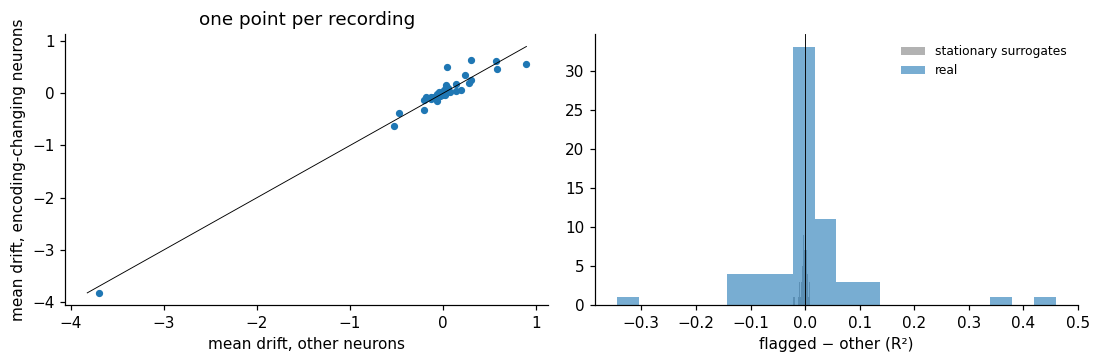

In [5]:
A = [r for r in rec.values() if r.get("diff") is not None and r.get("diff_surrogate") is not None]
diff = np.array([r["diff"] for r in A]); diff_s = np.array([r["diff_surrogate"] for r in A])
def wtest(x):
    return (float(wilcoxon(x).pvalue), float(np.median(x))) if len(x) >= 6 else (float("nan"), float(np.median(x)) if len(x) else float("nan"))
pA, medA = wtest(diff); pAs, medAs = wtest(diff_s)
ENRICHED = bool(pA < 0.05 and medA > 0 and not (pAs < 0.05))
print(f"recordings with annotations: {len(A)}; flagged neurons per recording: median {np.median([r['n_flagged'] for r in A]) if A else float('nan'):.0f}")
print(f"real:       median diff {medA:+.4f}, positive in {(diff > 0).sum()}/{len(diff)}, Wilcoxon p = {pA:.3g}")
print(f"surrogates: median diff {medAs:+.4f}, positive in {(diff_s > 0).sum()}/{len(diff_s)}, Wilcoxon p = {pAs:.3g}")
print("Registered rule -> drift enriched in encoding-changing neurons:", ENRICHED)
if len(A):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
    ax[0].scatter([r["drift_other"] for r in A], [r["drift_flagged"] for r in A], s=14)
    lim = [min(min(r["drift_other"], r["drift_flagged"]) for r in A), max(max(r["drift_other"], r["drift_flagged"]) for r in A)]
    ax[0].plot(lim, lim, "k-", lw=0.6); ax[0].set_xlabel("mean drift, other neurons"); ax[0].set_ylabel("mean drift, encoding-changing neurons")
    ax[0].set_title("one point per recording")
    ax[1].hist(diff_s, bins=20, alpha=0.6, label="stationary surrogates", color="0.5"); ax[1].hist(diff, bins=20, alpha=0.6, label="real", color="tab:blue")
    ax[1].axvline(0, c="k", lw=0.6); ax[1].set_xlabel("flagged − other (R²)"); ax[1].legend(frameon=False, fontsize=8)
    plt.tight_layout(); plt.show()

## 3 · B: does slow behavioral state explain the drift?

median gap: instantaneous +0.0091 | + slow behavior +0.0106 | + shifted slow behavior +0.0117
drift detected in: 47/68 (instantaneous), 50/68 (+ slow), 53/68 (+ shifted)
behavior-specific reduction: median +0.0000, Wilcoxon p = 0.625
Registered rules -> behavior-specific absorption: False | slow behavioral state explains the drift: False


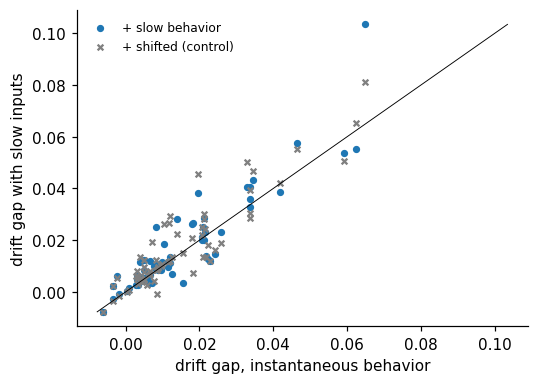

In [6]:
B = [r for r in rec.values() if "gap_inst" in r]
gi, gs, gh = (np.array([r[f"gap_{k}"] for r in B]) for k in ("inst", "slow", "shift"))
red_true, red_ctrl = gi - gs, gi - gh
pB, medB = wtest(red_true - red_ctrl)
n_inst = sum(r["gap_inst"] >= r["thr_inst"] for r in B); n_slow = sum(r["gap_slow"] >= r["thr_slow"] for r in B)
n_shift = sum(r["gap_shift"] >= r["thr_shift"] for r in B)
B_SPECIFIC = bool(pB < 0.05 and medB > 0)
B_EXPLAINS = bool(B_SPECIFIC and n_slow <= n_inst / 2)
print(f"median gap: instantaneous {np.median(gi):+.4f} | + slow behavior {np.median(gs):+.4f} | + shifted slow behavior {np.median(gh):+.4f}")
print(f"drift detected in: {n_inst}/{len(B)} (instantaneous), {n_slow}/{len(B)} (+ slow), {n_shift}/{len(B)} (+ shifted)")
print(f"behavior-specific reduction: median {medB:+.4f}, Wilcoxon p = {pB:.3g}")
print("Registered rules -> behavior-specific absorption:", B_SPECIFIC, "| slow behavioral state explains the drift:", B_EXPLAINS)
if len(B):
    fig, ax = plt.subplots(figsize=(5, 3.6))
    ax.scatter(gi, gs, s=14, label="+ slow behavior"); ax.scatter(gi, gh, s=14, marker="x", c="0.5", label="+ shifted (control)")
    lim = [min(gi.min(), gs.min(), gh.min()), max(gi.max(), gs.max(), gh.max())]; ax.plot(lim, lim, "k-", lw=0.6)
    ax.set_xlabel("drift gap, instantaneous behavior"); ax.set_ylabel("drift gap with slow inputs"); ax.legend(frameon=False, fontsize=8)
    plt.tight_layout(); plt.show()

In [7]:
out = {"A": {"n": len(A), "median_diff": medA, "p": pA, "median_diff_surrogate": medAs, "p_surrogate": pAs, "enriched": ENRICHED},
       "B": {"n": len(B), "median_gap": {"inst": float(np.median(gi)) if len(B) else None, "slow": float(np.median(gs)) if len(B) else None,
                                         "shift": float(np.median(gh)) if len(B) else None},
             "detected": {"inst": int(n_inst), "slow": int(n_slow), "shift": int(n_shift)}, "p_specific": pB,
             "median_specific_reduction": medB, "specific": B_SPECIFIC, "explains": B_EXPLAINS},
       "per_recording": rec}
json.dump(out, open(os.path.join(RESULTS, f"E3b_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E3b_result{TAG}.json")

saved E3b_result_laptop.json


## Results (laptop mode, 68 recordings, executed on the M1)

**A · Encoding change: not enriched.**

| | median diff (flagged − other, R²) | positive | Wilcoxon p |
|---|---|---|---|
| real recordings (65 with annotations; median 22 flagged neurons each) | −0.0009 | 32/65 | 0.85 |
| stationary surrogates | −0.0004 | 30/65 | 0.20 |

* The neurons Atanas et al. flagged as changing their behavioral encoding drift no more than the other neurons: half the recordings go each way.
* Single recordings show large differences in both directions (for example −0.34 in 2021-08-18-01 and +0.46 in 2023-01-17-14), but these are not consistent across worms.
* Registered rule → **ENRICHED = False**.

**B · Slow behavioral state: does not explain the drift.**

| inputs | median drift gap | drift detected |
|---|---|---|
| instantaneous behavior | +0.0091 | 47/68 |
| + slow behavior (60 s, 240 s) | +0.0106 | 50/68 |
| + slow behavior shifted by half the recording (control) | +0.0117 | 53/68 |

* The behavior-specific reduction is +0.0000 (median; Wilcoxon p = 0.63).
* Adding slow inputs makes the gap slightly **larger**, and it does so equally whether the slow behavior is aligned with the activity or shifted: extra input weights fitted on the past also go stale.
* Registered rules → **B_SPECIFIC = False, B_EXPLAINS = False**.

**Outcome: the last row of the table below.** The drift is diffuse: it is not concentrated in the neurons whose encoding changed, and it is not slow behavioral state. Two things are left to decide:
* what form the change takes (drives only? gains? a few global modes? unstructured rewiring?);
* whether a slow measurement change (bleaching, focus) could produce it.

Notebook 12 (E3c) tests both.

## 4 · Reading the result

| A (encoding) | B (slow state) | interpretation for C3 |
|---|---|---|
| enriched | does not explain | the "program" is rewritten in identifiable neurons: their behavioral encoding changes, and no slow behavioral state or activity-driven meta-program accounts for it. This is the strongest support for Brette's position in this data. Next: model the change as slowly modulated **input weights** (a gain/weight-modulating meta-program, E3c). |
| enriched | explains | encoding changes track behavioral state: a fixed program with state-dependent gains. The computer metaphor survives with behavioral state as an input. |
| not enriched | explains | drift is mostly state-dependence of the drives; the authors' encoding changes are not where the forecast drift is |
| **not enriched ← observed** | **does not explain ← observed** | the drift is diffuse, and neither explanation holds; slow imaging changes (bleaching) and unmodelled inputs remain candidates. **Next: E3c (Notebook 12) — what form does the change take, and is it measurement?** |

**Limits.**
* The baseline recordings have no neuron identities, so all of this is connectome-free.
* Per-neuron drift compares a program fitted on half the recording with one fitted on a quarter, so it underestimates drift, equally for all neurons.
* The flagged neurons come from the authors' encoding model, which differs from ours; agreement between the two is the point of test A.